In [116]:
import os, re
import pandas as pd 
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [117]:
def load_imdb_dataframe(base_dir="imdb_reviews_dataset"):
    """
    Load IMDB reviews from train and test folders into a single DataFrame.

    - Reads all .txt files in 'pos' and 'neg' subfolders of 'train' and 'test'
    - Assigns labels 'positive' for pos and 'negative' for neg
    - Returns a DataFrame with columns: 'review' (text) and 'label'
    """
    data = []
    labels = {"pos": "positive", "neg": "negative"}

    for split in ("train", "test"):
        for folder, label in labels.items():
            path = os.path.join(base_dir, split, folder)

            for file in os.listdir(path):
                if file.endswith(".txt"):
                    with open(os.path.join(path, file), encoding="utf-8") as f:
                        data.append({
                            "review": f.read().strip(),
                            "label": label
                        })

    return pd.DataFrame(data)

In [118]:
# Load IMDB reviews into a single DataFrame
data = load_imdb_dataframe()

print("Columns in the dataset:", data.columns.tolist())
print(f"Dataset shape: {data.shape[0]} reviews, {data.shape[1]} columns")
print("First 10 reviews:\n", data.head(10))


Columns in the dataset: ['review', 'label']
Dataset shape: 50000 reviews, 2 columns
First 10 reviews:
                                               review     label
0  For a movie that gets no respect there sure ar...  positive
1  Bizarre horror movie filled with famous faces ...  positive
2  A solid, if unremarkable film. Matthau, as Ein...  positive
3  It's a strange feeling to sit alone in a theat...  positive
4  You probably all already know this by now, but...  positive
5  I saw the movie with two grown children. Altho...  positive
6  You're using the IMDb.<br /><br />You've given...  positive
7  This was a good film with a powerful message o...  positive
8  Made after QUARTET was, TRIO continued the qua...  positive
9  For a mature man, to admit that he shed a tear...  positive


In [119]:
def clean_review(text: str) -> str:
    """
    Clean a movie review by:
    1. Removing HTML tags.
    2. Converting text to lowercase.
    3. Removing all non-alphabetic characters.
    4. Normalizing whitespace (removing extra spaces).
    """
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [120]:
data["review"] = data["review"].apply(clean_review)
data.head(10)

,review,label
0,for a movie that gets no respect there sure ar...,positive
1,bizarre horror movie filled with famous faces ...,positive
2,a solid if unremarkable film matthau as einste...,positive
3,it s a strange feeling to sit alone in a theat...,positive
4,you probably all already know this by now but ...,positive
5,i saw the movie with two grown children althou...,positive
6,you re using the imdb you ve given some hefty ...,positive
7,this was a good film with a powerful message o...,positive
8,made after quartet was trio continued the qual...,positive
9,for a mature man to admit that he shed a tear ...,positive


Review counts by class:
label
positive    25000
negative    25000
Name: count, dtype: int64 



/var/folders/5h/wdf3vc9s0cb3k4pj_zh03f300000gn/T/ipykernel_50374/2338223634.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")


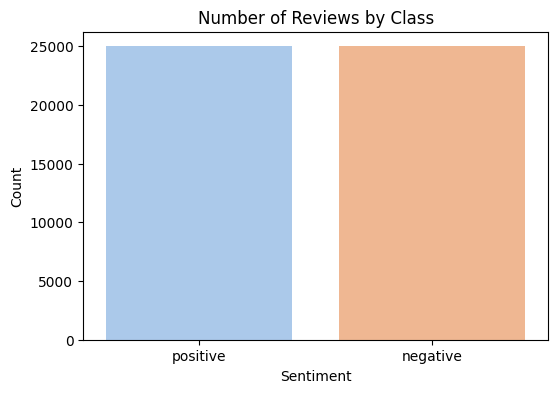

In [121]:
#Shows the number of positive vs negative and ensures classes are balanced.
import matplotlib.pyplot as plt
import seaborn as sns

# Count number of positive and negative reviews
label_counts = data['label'].value_counts()

print("Review counts by class:")
print(label_counts,"\n")

plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="pastel")
plt.title("Number of Reviews by Class")
plt.ylabel("Count")
plt.xlabel("Sentiment")
plt.show()


In [122]:
from sklearn.model_selection import train_test_split


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    data["review"],
    data["label"],
    test_size=0.2,
    random_state=42,
)


In [123]:
# Initialize the TF-IDF vectorizer
tfid_vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2)
)

# Fit the vectorizer on the training data and transform it into TF-IDF features
X_train_tfidf = tfid_vectorizer.fit_transform(X_train)
X_test_tfidf = tfid_vectorizer.transform(X_test)


In [124]:
# Initialize the Count vectorizer
count_vectorizer = CountVectorizer(
    max_features=50_000,
    ngram_range=(1, 2)
)

X_train_vec = count_vectorizer.fit_transform(X_train)
X_test_vec = count_vectorizer.transform(X_test)


In [125]:
# Using Logistic Regression
logistic_model = LogisticRegression(max_iter=1000, n_jobs=-1)
logistic_model.fit(X_train_tfidf, y_train)

# Make predictions
logistic_model_y_pred = logistic_model.predict(X_test_tfidf)

# Compute accuracy
logistic_accuracy = accuracy_score(y_test, logistic_model_y_pred)

# Print results
print("Logistic Regression Evaluation Metrics")
print("--------------------------------------")
print(f"Accuracy : {logistic_accuracy:.4f}")
print("\nClassification Report:\n\n", classification_report(y_test, logistic_model_y_pred))


Logistic Regression Evaluation Metrics
--------------------------------------
Accuracy : 0.9054

Classification Report:

               precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4945
    positive       0.90      0.92      0.91      5055

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



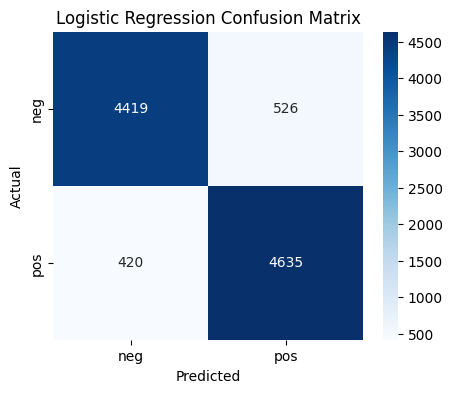

In [126]:
# -----------------------------
# Logistic Regression Confusion Matrix
# -----------------------------
cm_lr = confusion_matrix(y_test, logistic_model_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [127]:
# Using Support Vector Machine
svm_model = LinearSVC(C=1.0, max_iter=1000)
svm_model.fit(X_train_vec, y_train)

svm_model_y_pred = svm_model.predict(X_test_vec)

svm_accuracy = accuracy_score(y_test, svm_model_y_pred)

# Print results
print("Support Vector Machine Evaluation Metrics")
print("--------------------------------------")
print(f"Accuracy : {svm_accuracy:.4f}")
print("\nClassification Report:\n\n", classification_report(y_test, svm_model_y_pred))


Support Vector Machine Evaluation Metrics
--------------------------------------
Accuracy : 0.8880

Classification Report:

               precision    recall  f1-score   support

    negative       0.89      0.89      0.89      4945
    positive       0.89      0.89      0.89      5055

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



/Users/dashivam06/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


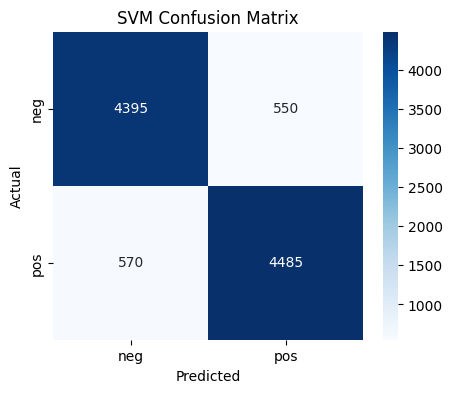

In [128]:
# -----------------------------
# SVM Confusion Matrix
# -----------------------------
cm_svm = confusion_matrix(y_test, svm_model_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [129]:
# Using Multinomial Naive Bayes
mnb_model = MultinomialNB(alpha=1.0)
mnb_model.fit(X_train_vec, y_train)

mnb_model_y_pred = mnb_model.predict(X_test_vec)

mnb_accuracy = accuracy_score(y_test, mnb_model_y_pred)


# Print results
print("Multinomial Naive Bayes Evaluation Metrics")
print("--------------------------------------")
print(f"Accuracy : {mnb_accuracy:.4f}")
print("\nClassification Report:\n\n", classification_report(y_test, mnb_model_y_pred))


Multinomial Naive Bayes Evaluation Metrics
--------------------------------------
Accuracy : 0.8668

Classification Report:

               precision    recall  f1-score   support

    negative       0.86      0.87      0.87      4945
    positive       0.87      0.86      0.87      5055

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



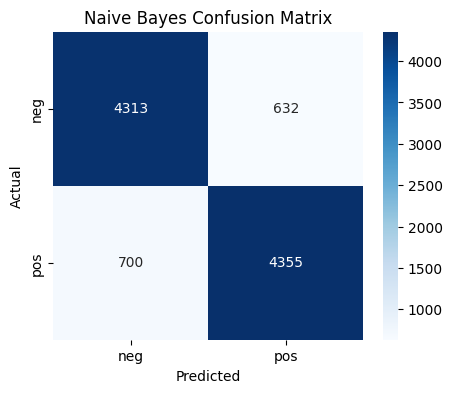

In [130]:
# -----------------------------
# Naive Bayes Confusion Matrix
# -----------------------------
cm_nb = confusion_matrix(y_test, mnb_model_y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
plt.title("Naive Bayes Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

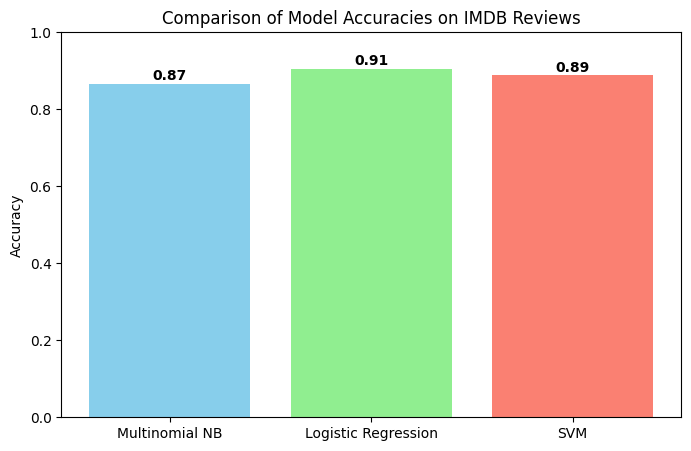

In [131]:
# Bar chart showing and comparing the accuracy of the three models
accuracy_scores = {
    "Multinomial NB": mnb_accuracy,      
    "Logistic Regression": logistic_accuracy,  
    "SVM": svm_accuracy                
}

# Plotting
plt.figure(figsize=(8,5))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(0, 1)  
plt.ylabel("Accuracy")
plt.title("Comparison of Model Accuracies on IMDB Reviews")
for i, v in enumerate(accuracy_scores.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()


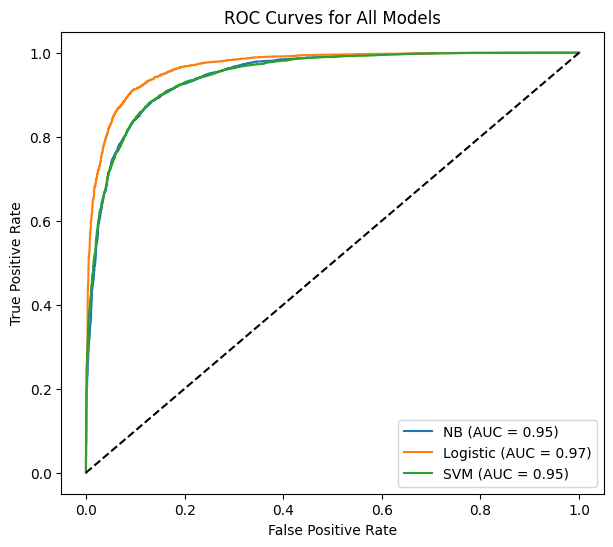

In [132]:
# ROC Curve for all models
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)  

# It plots ROC curves to evaluate and compare how well each model distinguishes between positive and negative reviews
plt.figure(figsize=(7,6))
for name, clf_model in [("NB", mnb_model), ("Logistic", logistic_model), ("SVM", svm_model)]:
    if hasattr(clf_model, "predict_proba"):
        y_score = clf_model.predict_proba(X_test_tfidf)[:,1]
    else:  # SVM
        y_score = clf_model.decision_function(X_test_tfidf)
    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()
